## Wilks' theorem — validity check

Part 4 computes discovery significance using Wilks' theorem: under the null hypothesis (background only), the test statistic q = 2 * delta_NLL follows a chi-squared(1) distribution, giving Z = sqrt(q). This is an asymptotic result and has a known subtlety here: the true signal fraction under H0 is f_s = 0, which sits on the boundary of the allowed parameter space (f_s >= 0). In that case the asymptotic distribution is not chi-squared(1) but a 50/50 mixture of a point mass at zero and chi-squared(1). We test this directly by generating background-only toys and comparing the q distribution to chi-squared(1).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from scipy.optimize import minimize
from scipy.stats import norm, chi2

os.makedirs('../plots', exist_ok=True)

In [2]:
#load fitted background slope and BDT efficiencies
with open('../fit_params.json') as fh:
    fit_params = json.load(fh)
with open('../bdt_results.json') as fh:
    bdt_results = json.load(fh)

lam_fit = fit_params['lam_bkg']
sig_eff = bdt_results['signal_efficiency']
bkg_eff = bdt_results['background_efficiency']

MASS_LO, MASS_HI = 4.0, 6.0
MU_SIG, SIG_SIG  = 5.0, 0.03
N_BKG_YEAR       = 2000 * bkg_eff

print(f'lambda (background slope): {lam_fit:.4f}')
print(f'expected background per year after BDT: {N_BKG_YEAR:.1f}')

lambda (background slope): 0.0283
expected background per year after BDT: 145.2


In [3]:
#redefine the PDF and fit functions used in mass_fit.ipynb
def exp_pdf(m, lam):
    norm_factor = (np.exp(-lam * MASS_LO) - np.exp(-lam * MASS_HI)) / lam
    return np.exp(-lam * m) / norm_factor

def composite_pdf(m, fs, lam):
    return fs * norm.pdf(m, MU_SIG, SIG_SIG) + (1 - fs) * exp_pdf(m, lam)

def sample_exp(lam, n, rng):
    u = rng.uniform(0, 1, size=n)
    return -np.log(np.exp(-lam * MASS_LO) - u * (np.exp(-lam * MASS_LO) - np.exp(-lam * MASS_HI))) / lam

def generate_toy(n_sig_mean, n_bkg_mean, lam, rng):
    n_sig = rng.poisson(n_sig_mean)
    n_bkg = rng.poisson(n_bkg_mean)
    masses = np.concatenate([rng.normal(MU_SIG, SIG_SIG, n_sig), sample_exp(lam, n_bkg, rng)])
    return masses[(masses >= MASS_LO) & (masses <= MASS_HI)]

def nll_composite(params, masses):
    fs, lam = params
    if fs < 0 or fs > 1 or lam <= 0:
        return 1e10
    pdf_vals = composite_pdf(masses, fs, lam)
    return -np.sum(np.log(pdf_vals)) if np.all(pdf_vals > 0) else 1e10

def nll_bkg_only(params, masses):
    lam = params[0]
    return -np.sum(np.log(exp_pdf(masses, lam))) if lam > 0 else 1e10

def fit_toy(masses):
    res = minimize(nll_composite, x0=[0.02, lam_fit], args=(masses,), method='Nelder-Mead',
                   options={'xatol': 1e-5, 'fatol': 1e-5, 'maxiter': 5000})
    return float(res.x[0]), float(res.x[1]), float(res.fun)

def fit_bkg_only(masses):
    res = minimize(nll_bkg_only, x0=[lam_fit], args=(masses,), method='Nelder-Mead')
    return float(res.fun)

In [4]:
#generate background-only toys (no signal injected) to test Wilks under H0
rng_h0    = np.random.default_rng(seed=99)
N_TOYS_H0 = 500
toys_h0   = [generate_toy(0.0, N_BKG_YEAR, lam_fit, rng_h0) for _ in range(N_TOYS_H0)]

q_h0 = []
for toy in toys_h0:
    _, _, nll1 = fit_toy(toy)
    nll0 = fit_bkg_only(toy)
    q_h0.append(max(0.0, 2.0 * (nll0 - nll1)))
q_h0 = np.array(q_h0)

print(f'fraction of toys with q = 0: {(q_h0 == 0).mean():.3f}  (expected ~0.5 from boundary effect)')
print(f'mean q over all toys: {q_h0.mean():.3f}  (expected ~0.5 from boundary mixture)')

fraction of toys with q = 0: 0.130  (expected ~0.5 from boundary effect)
mean q over all toys: 0.439  (expected ~0.5 from boundary mixture)


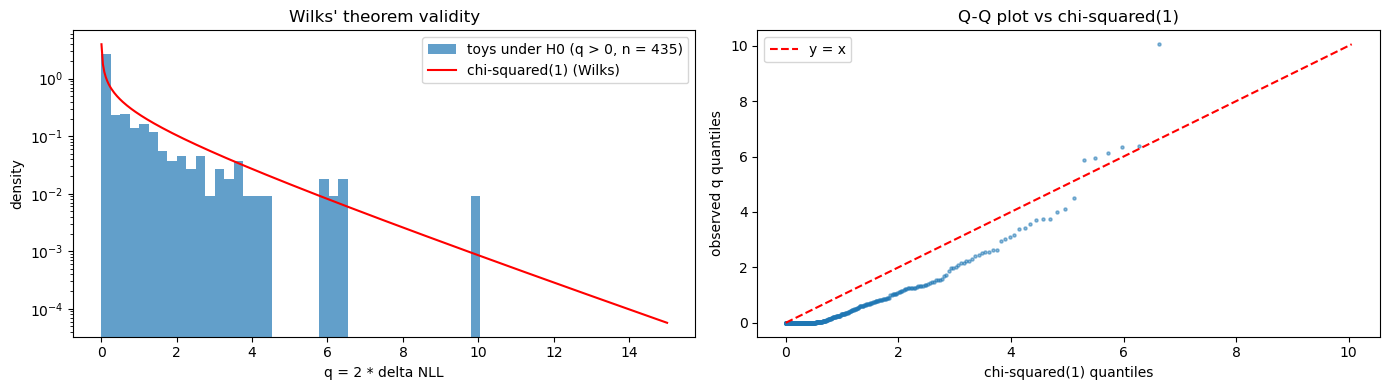

tail probability check:
  P(q > 1^2 = 1):  observed = 0.146,  chi-squared(1) = 0.317
  P(q > 2^2 = 4):  observed = 0.018,  chi-squared(1) = 0.046
  P(q > 3^2 = 9):  observed = 0.002,  chi-squared(1) = 0.003


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

#left: histogram vs chi-squared(1)
ax      = axes[0]
q_range = np.linspace(0.01, 15, 400)
ax.hist(q_h0[q_h0 > 0], bins=40, density=True, alpha=0.7,
        label=f'toys under H0 (q > 0, n = {int((q_h0 > 0).sum())})')
ax.plot(q_range, chi2.pdf(q_range, df=1), color='red', label='chi-squared(1) (Wilks)')
ax.set_xlabel('q = 2 * delta NLL')
ax.set_ylabel('density')
ax.set_yscale('log')
ax.legend()
ax.set_title("Wilks' theorem validity")

#right: Q-Q plot against chi-squared(1)
ax        = axes[1]
q_nonzero = np.sort(q_h0[q_h0 > 0])
n         = len(q_nonzero)
th_quants = chi2.ppf(np.linspace(0.01, 0.99, n), df=1)
ax.scatter(th_quants, q_nonzero, s=5, alpha=0.5)
lim = max(th_quants.max(), q_nonzero.max())
ax.plot([0, lim], [0, lim], color='red', linestyle='--', label='y = x')
ax.set_xlabel('chi-squared(1) quantiles')
ax.set_ylabel('observed q quantiles')
ax.set_title('Q-Q plot vs chi-squared(1)')
ax.legend()

plt.tight_layout()
plt.savefig('../plots/wilks_validity.png', dpi=150, bbox_inches='tight')
plt.show()

#compare tail probabilities to chi-squared(1) prediction
print('tail probability check:')
for z in [1, 2, 3]:
    obs = (q_h0 > float(z**2)).mean()
    exp = chi2.sf(float(z**2), df=1)
    print(f'  P(q > {z}^2 = {z**2}):  observed = {obs:.3f},  chi-squared(1) = {exp:.3f}')